# Pete Crow-Armstrong vs Shohei Ohtani: MVP Case

FanGraphs leaderboard exports, full 2026 season as of 8/9. Run top to bottom from this folder.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

FIG = "../figures"
NAVY, RED, GRAY = "#1d3557", "#c1121f", "#888888"
read = lambda f: pd.read_csv(f, encoding="utf-8-sig")
ip_to_float = lambda v: int(v) + round((v % 1) * 10) / 3     # FanGraphs 85.2 IP = 85 2/3

## 1. Hitting: plus stats and base running vs the 142-hitter pool

In [2]:
# FanGraphs exports, full 2026 season as of 8/9
plus = read("hitters_plus_stats_2026.csv")        # 142 hitters, 366+ PA
adv = read("hitters_advanced_2026.csv")
sp_adv = read("sp_advanced_2026.csv")             # 58 starters, 116+ IP
dodgers_adv = read("dodgers_pitchers_advanced_2026.csv")
dodgers_sc = read("dodgers_pitchers_statcast_2026.csv")
fld = read("fielders_defense_2026.csv")           # 122 fielders, 644+ inn

OHTANI, PCA = "Shohei Ohtani", "Pete Crow-Armstrong"
hit = plus.merge(adv[["PlayerId", "Spd", "wSB"]], on="PlayerId")
row = lambda name: hit[hit["Name"] == name].iloc[0]
o, p = row(OHTANI), row(PCA)
STATS = ["wRC+", "OBP+", "SLG+", "ISO+", "Spd", "wSB"]
pool_avg = {s: hit[s].mean() for s in STATS}

print(pd.DataFrame({"Ohtani": [o[s] for s in STATS], "PCA": [p[s] for s in STATS], "Pool avg": [pool_avg[s] for s in STATS]}, index=STATS).round(2))

      Ohtani     PCA  Pool avg
wRC+  152.55  155.71    111.40
OBP+  124.04  121.08    104.64
SLG+  134.84  134.29    107.23
ISO+  158.44  161.50    110.54
Spd     3.94    7.64      4.37
wSB    -0.78    2.30      0.12


## 2. Pitching vs defensive value

In [3]:
# Ohtani pitching runs above average: (pool-average SP FIP - his FIP) x IP / 9
o_pitch = dodgers_adv[dodgers_adv["Name"] == OHTANI].iloc[0]
o_ip_raw = dodgers_sc[dodgers_sc["Name"] == OHTANI]["IP"].iloc[0]
lg_fip = sp_adv["FIP"].mean()
pitch_runs = (lg_fip - o_pitch["FIP"]) * ip_to_float(o_ip_raw) / 9

# Crow-Armstrong defensive value: FanGraphs Def
pca_fld = fld[fld["Name"] == PCA].iloc[0]
def_runs = pca_fld["Def"]
print(f"Ohtani: FIP {o_pitch['FIP']:.2f} vs SP pool {lg_fip:.2f} over {o_ip_raw} IP -> {pitch_runs:.1f} runs")
print(f"PCA: Def {def_runs:.1f} over {pca_fld['Inn']} inn (FRV {pca_fld['FRV']}, OAA {pca_fld['OAA']:.0f}, DRS {pca_fld['DRS']})")

Ohtani: FIP 2.60 vs SP pool 3.73 over 85.2 IP -> 10.8 runs
PCA: Def 21.7 over 1011.2 inn (FRV 24, OAA 22, DRS 14)


## 3. Charts

In [4]:
def panel(ax, title, labels, vals, fmt, avg=None):
    bars = ax.bar(labels, vals, color=[NAVY, RED], width=0.55)
    ax.set_title(title, fontsize=11.5, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if avg is not None:
        ax.axhline(avg, color=GRAY, linewidth=1, linestyle="--")
    lo = min(0, min(vals))
    ax.set_ylim(lo * 1.8 if lo < 0 else 0, max(vals) * 1.2 if lo >= 0 else max(vals) * 1.25)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v, fmt(v), ha="center", va="bottom" if v >= 0 else "top",
                fontsize=10, fontweight="bold")

FMT = {"wRC+": "{:.1f}".format, "OBP+": "{:.1f}".format, "SLG+": "{:.1f}".format, "ISO+": "{:.1f}".format,
       "Spd": "{:.1f}".format, "wSB": "{:+.2f}".format}
legend = [Patch(color=NAVY, label="Ohtani"), Patch(color=RED, label="Crow-Armstrong"),
          Line2D([0], [0], color=GRAY, linestyle="--", linewidth=1, label="Pool Average")]

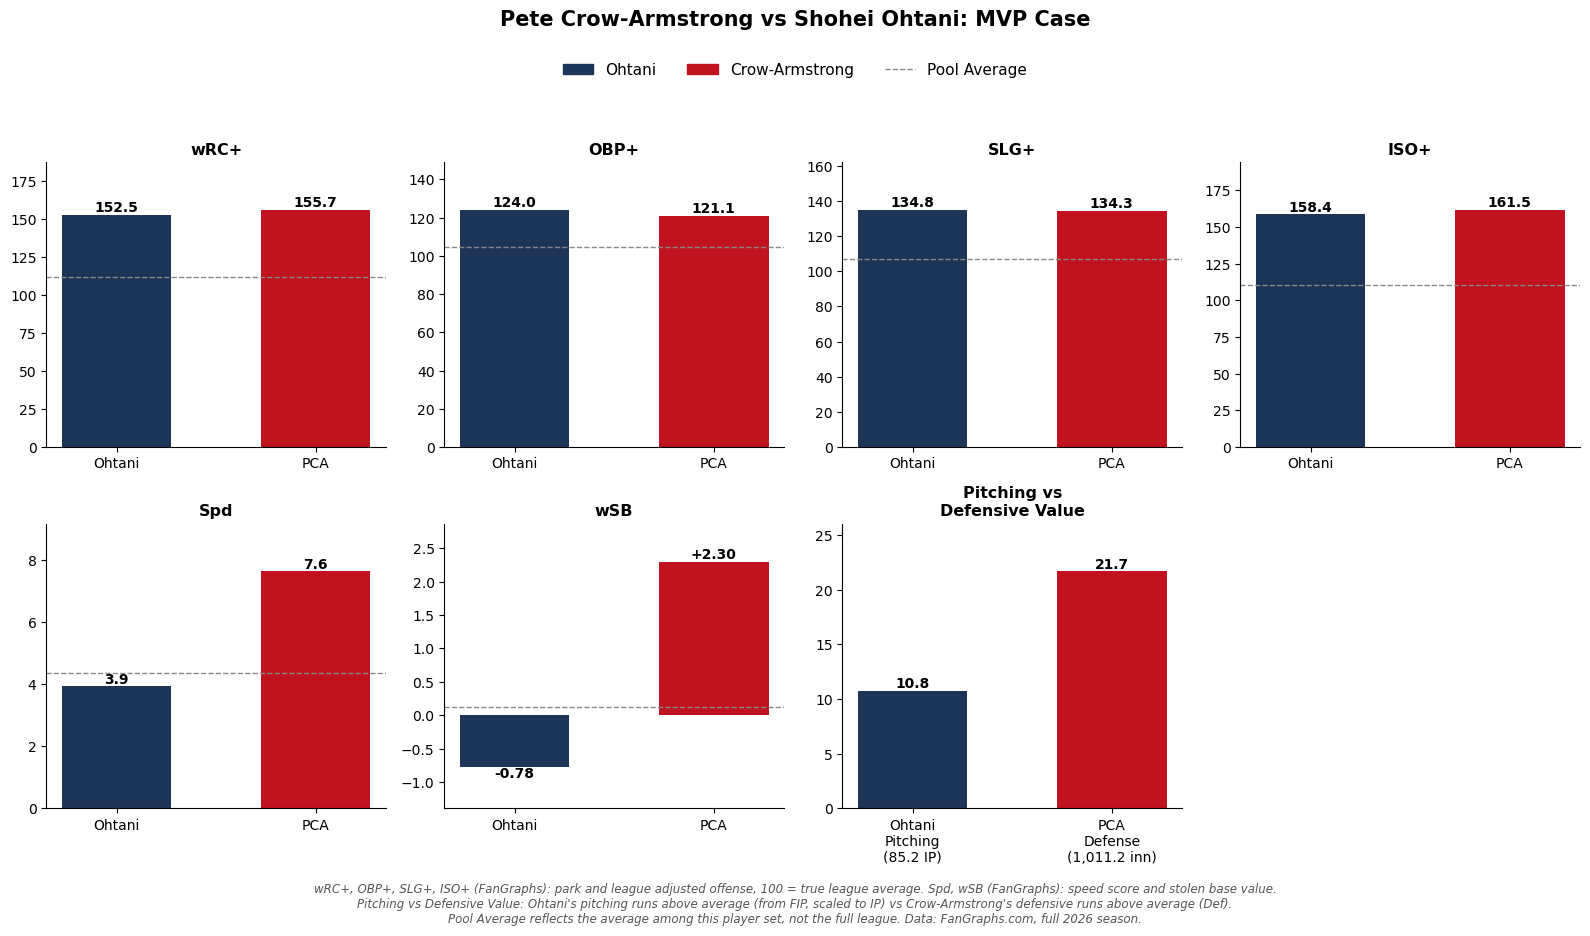

In [5]:
# Chart: MVP case (offense, base running, pitching vs defense)
fig, axes = plt.subplots(2, 4, figsize=(16, 8.7))
fig.patch.set_facecolor("white")
axf = axes.flatten()
for ax, s in zip(axf, STATS):
    panel(ax, s, ["Ohtani", "PCA"], [o[s], p[s]], FMT[s], pool_avg[s])
panel(axf[6], "Pitching vs\nDefensive Value",
      [f"Ohtani\nPitching\n({o_ip_raw} IP)", f"PCA\nDefense\n({pca_fld['Inn']:,} inn)"], [pitch_runs, def_runs], "{:.1f}".format)
axf[7].axis("off")
fig.legend(handles=legend, loc="upper center", ncol=3, frameon=False, fontsize=11, bbox_to_anchor=(0.5, 0.955))
fig.suptitle("Pete Crow-Armstrong vs Shohei Ohtani: MVP Case", fontsize=15, fontweight="bold", y=1.0)
fig.text(0.5, -0.05, "wRC+, OBP+, SLG+, ISO+ (FanGraphs): park and league adjusted offense, 100 = true league average. Spd, wSB (FanGraphs): speed score and stolen base value.\n"
         "Pitching vs Defensive Value: Ohtani's pitching runs above average (from FIP, scaled to IP) vs Crow-Armstrong's defensive runs above average (Def).\n"
         "Pool Average reflects the average among this player set, not the full league. Data: FanGraphs.com, full 2026 season.",
         ha="center", fontsize=8.5, style="italic", color="#555555")
plt.tight_layout(rect=(0, 0, 1, 0.905))
plt.savefig(f"{FIG}/pca_vs_ohtani_mvp_2026.png", dpi=200, bbox_inches="tight")
plt.show()

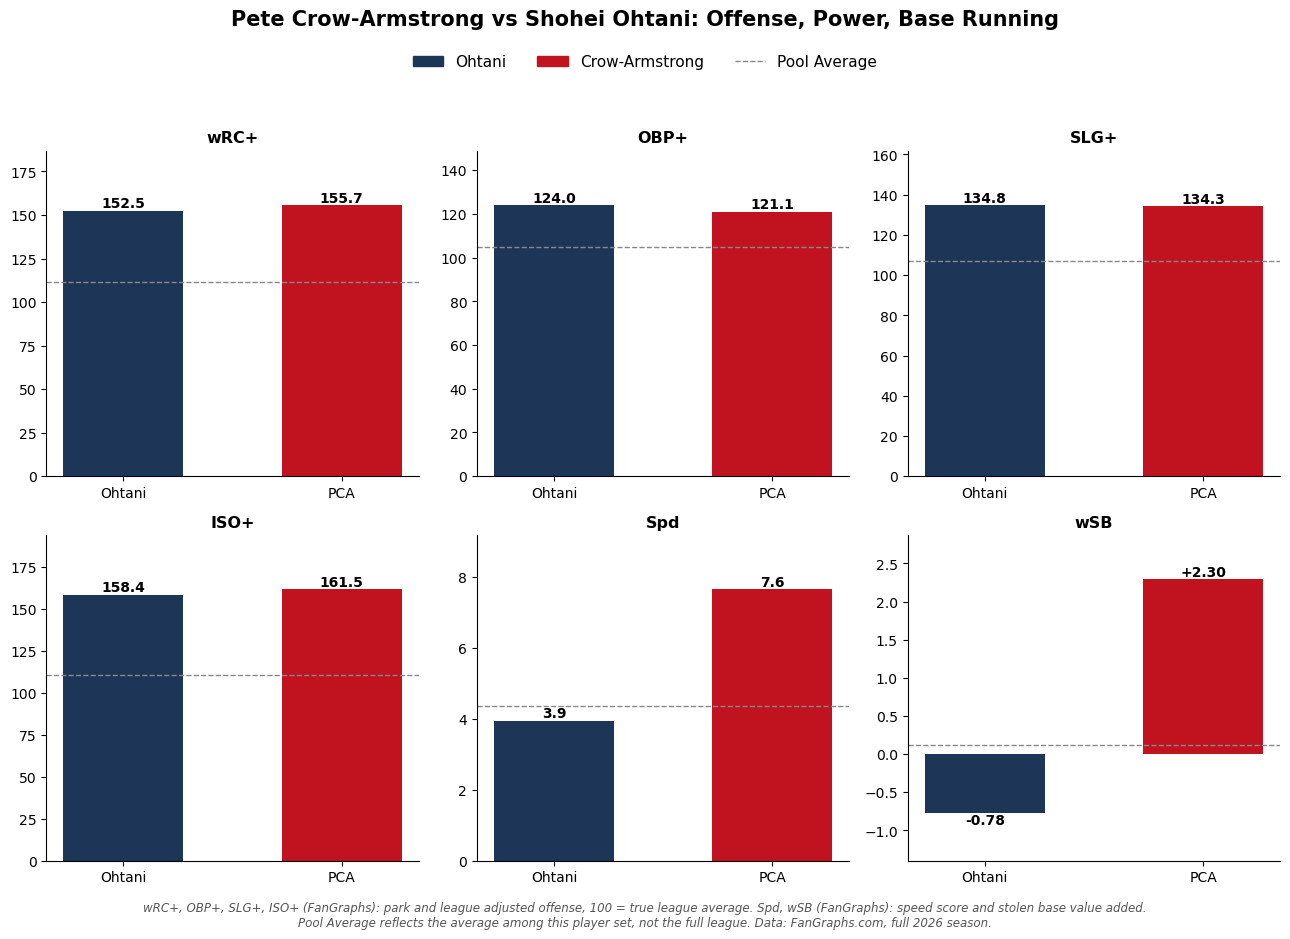

In [6]:
# Chart: offense, power, base running only
fig, axes = plt.subplots(2, 3, figsize=(13, 8.9))
fig.patch.set_facecolor("white")
for ax, s in zip(axes.flatten(), STATS):
    panel(ax, s, ["Ohtani", "PCA"], [o[s], p[s]], FMT[s], pool_avg[s])
fig.legend(handles=legend, loc="upper center", ncol=3, frameon=False, fontsize=11, bbox_to_anchor=(0.5, 0.965))
fig.suptitle("Pete Crow-Armstrong vs Shohei Ohtani: Offense, Power, Base Running", fontsize=15, fontweight="bold", y=1.0)
fig.text(0.5, -0.03, "wRC+, OBP+, SLG+, ISO+ (FanGraphs): park and league adjusted offense, 100 = true league average. Spd, wSB (FanGraphs): speed score and stolen base value added.\n"
         "Pool Average reflects the average among this player set, not the full league. Data: FanGraphs.com, full 2026 season.",
         ha="center", fontsize=8.5, style="italic", color="#555555")
plt.tight_layout(rect=(0, 0, 1, 0.92))
plt.savefig(f"{FIG}/pca_vs_ohtani_raw_stats_2026.png", dpi=200, bbox_inches="tight")
plt.show()